# TT-06 — Naive Bayes: Lọc tin nhắn rác cho tổng đài viễn thông


## Import thư viện

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer,
)
import joblib
import json
import os

PROJECT_ROOT = Path.cwd().parent
os.makedirs(PROJECT_ROOT / "reports", exist_ok=True)
os.makedirs(PROJECT_ROOT / "models", exist_ok=True)

RANDOM_STATE = 42
TARGET_PRECISION = 0.98

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Nạp dữ liệu, kiểm tra encoding

In [2]:
DATA_PATH = PROJECT_ROOT / "dataset" / "spam.csv"

df = pd.read_csv(DATA_PATH, encoding="latin-1")

df = df.iloc[:, :2]
df.columns = ["label", "text"]
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(4) * 100)  
print(df.shape)
print(df.head())


label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64
(5572, 2)
  label  \
0   ham   
1   ham   
2  spam   
3   ham   
4   ham   

                                                                                                                      text  
0          Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...  
1                                                                                            Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...  
3                                                                        U dun say so early hor... U c already then say...  
4                                                            Nah I don't think he goes to usf, he lives around here though  


## 2. Kiểm tra & loại tin nhắn trùng lặp

In [3]:
n_dup = df.duplicated().sum()
print(f"Số dòng trùng lặp: {n_dup} / {len(df)} ({n_dup/len(df)*100:.1f}%)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Sau khi loại trùng: {df.shape}")

Số dòng trùng lặp: 403 / 5572 (7.2%)
Sau khi loại trùng: (5169, 2)


## 3. EDA: độ dài tin nhắn ham vs spam

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


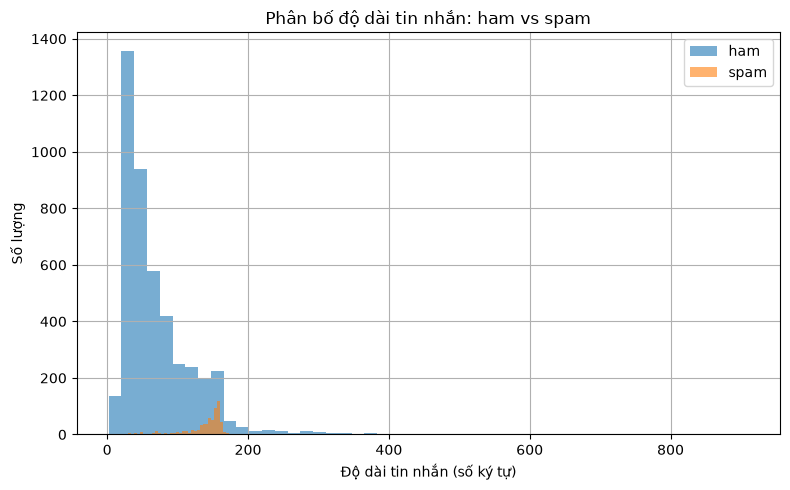

In [4]:
df["length"] = df["text"].str.len()
display(df.groupby("label")["length"].describe())

fig, ax = plt.subplots()
df[df.label == "ham"]["length"].hist(bins=50, alpha=0.6, label="ham", ax=ax)
df[df.label == "spam"]["length"].hist(bins=50, alpha=0.6, label="spam", ax=ax)
ax.set_xlabel("Độ dài tin nhắn (số ký tự)")
ax.set_ylabel("Số lượng")
ax.set_title("Phân bố độ dài tin nhắn: ham vs spam")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/do_dai_tin.png", dpi=120)
plt.show()

## 4. Chia train/test/Validation & Baseline

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)
print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"Baseline (đoán 'ham' hết) — accuracy trên test: {dummy_acc:.4f}  <-- cao nhưng vô dụng")

Train: 3308 | Validation: 827 | Test: 1034
Baseline (đoán 'ham' hết) — accuracy trên test: 0.8733  <-- cao nhưng vô dụng


## 5-7. So sánh 3 tổ hợp

In [6]:
configs = {
    "Count + Multinomial": make_pipeline(
        CountVectorizer(lowercase=True), MultinomialNB()
    ),
    "TFIDF + Multinomial": make_pipeline(
        TfidfVectorizer(lowercase=True, sublinear_tf=True), MultinomialNB()
    ),
    "TFIDF + Bernoulli": make_pipeline(
        TfidfVectorizer(lowercase=True, sublinear_tf=True), BernoulliNB()
    ),
}

results = []
fitted_pipes = {}

for name, pipe in configs.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    results.append({
        "model": name,
        "precision": precision_score(y_val, y_pred, pos_label="spam"),
        "recall": recall_score(y_val, y_pred, pos_label="spam"),
        "f1": f1_score(y_val, y_pred, pos_label="spam"),
    })
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df


,model,precision,recall,f1
0,Count + Multinomial,0.977778,0.846154,0.907216
2,TFIDF + Bernoulli,1.000000,0.644231,0.783626
1,TFIDF + Multinomial,1.000000,0.490385,0.658065


## 8. Dò alpha và ngram_range

In [7]:
pipe_grid = make_pipeline(
    TfidfVectorizer(lowercase=True, min_df=2, max_df=0.9, sublinear_tf=True),
    MultinomialNB(),
)
param_grid = {
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
    "multinomialnb__alpha": [0.01, 0.1, 0.5, 1.0],
}
spam_f1_scorer = make_scorer(f1_score, pos_label="spam")
grid = GridSearchCV(pipe_grid, param_grid, scoring=spam_f1_scorer, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV spam-F1: {grid.best_score_:.4f}")
best_pipe = grid.best_estimator_
y_pred_val_default = best_pipe.predict(X_val)
print()
print("=== Validation, ngưỡng mặc định 0.5 ===")
print(classification_report(y_val, y_pred_val_default, digits=4))

Best params: {'multinomialnb__alpha': 0.1, 'tfidfvectorizer__ngram_range': (1, 2)}
Best CV spam-F1: 0.9446

=== Validation, ngưỡng mặc định 0.5 ===
              precision    recall  f1-score   support

         ham     0.9730    0.9986    0.9857       723
        spam     0.9882    0.8077    0.8889       104

    accuracy                         0.9746       827
   macro avg     0.9806    0.9032    0.9373       827
weighted avg     0.9750    0.9746    0.9735       827



In [8]:
cv_results = pd.DataFrame(grid.cv_results_)[
    ["param_tfidfvectorizer__ngram_range", "param_multinomialnb__alpha", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
cv_results.columns = ["ngram_range", "alpha", "mean_f1_weighted", "std"]
cv_results.reset_index(drop=True)

,ngram_range,alpha,mean_f1_weighted,std
0,"(1, 2)",0.10,0.944555,0.026994
1,"(1, 2)",0.01,0.941825,0.022689
2,"(1, 1)",0.10,0.937205,0.023645
3,"(1, 1)",0.01,0.935283,0.032153
4,"(1, 1)",0.50,0.906615,0.028751
5,"(1, 2)",0.50,0.892326,0.021842
6,"(1, 1)",1.00,0.854380,0.023587
7,"(1, 2)",1.00,0.803396,0.029122


## 9. Top 20 từ có xác suất cao nhất cho lớp spam


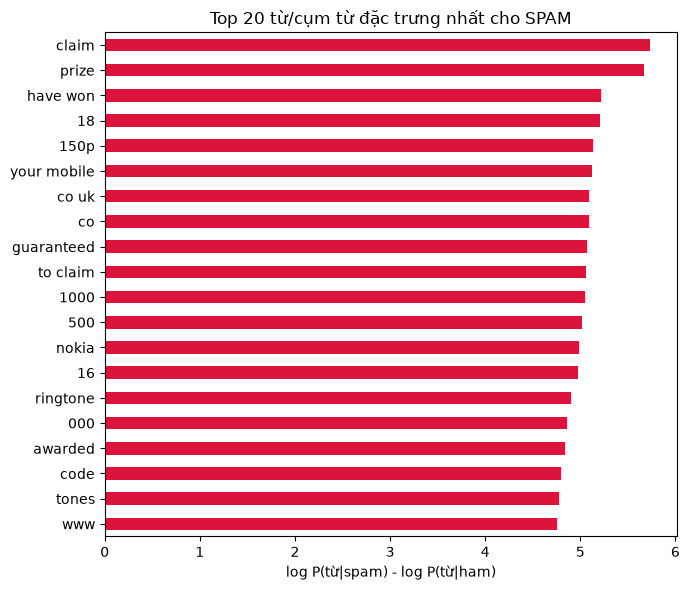

,từ/cụm từ,log_ratio
0,claim,5.730392
1,prize,5.667031
2,have won,5.220102
3,18,5.205215
4,150p,5.130418
5,your mobile,5.119354
6,co uk,5.086229
7,co,5.086229
8,guaranteed,5.066283
9,to claim,5.055017


In [9]:
vectorizer = best_pipe.named_steps["tfidfvectorizer"]
nb_model = best_pipe.named_steps["multinomialnb"]

feature_names = vectorizer.get_feature_names_out()
spam_idx = list(nb_model.classes_).index("spam")
ham_idx = list(nb_model.classes_).index("ham")

log_ratio = nb_model.feature_log_prob_[spam_idx] - nb_model.feature_log_prob_[ham_idx]
top20_spam = pd.Series(log_ratio, index=feature_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
top20_spam.sort_values().plot(kind="barh", ax=ax, color="crimson")
ax.set_xlabel("log P(từ|spam) - log P(từ|ham)")
ax.set_title("Top 20 từ/cụm từ đặc trưng nhất cho SPAM")
plt.tight_layout()
plt.savefig("../reports/top_tu_spam.png", dpi=120)
plt.show()

top20_spam.reset_index().rename(columns={"index": "từ/cụm từ", 0: "log_ratio"})

## 10. Chọn ngưỡng để đạt precision ≥ 0.98

In [ ]:
y_val_proba = best_pipe.predict_proba(X_val)[:, spam_idx]
y_val_bin = (y_val == "spam").astype(int)
precisions, recalls, thresholds = precision_recall_curve(y_val_bin, y_val_proba)
valid_idx = np.where(precisions[:-1] >= TARGET_PRECISION)[0]

if len(valid_idx) > 0:
    idx = valid_idx[0] 
    chosen_threshold = thresholds[idx]
    print(f"[Validation] Ngưỡng chọn: {chosen_threshold:.4f}")
    print(f"[Validation] Precision đạt được: {precisions[idx]:.4f}")
    print(f"[Validation] Recall tương ứng:   {recalls[idx]:.4f}")
else:
    chosen_threshold = 0.5
    print(f"[Validation] Không đạt được precision >= {TARGET_PRECISION}, dùng ngưỡng mặc định 0.5")

y_test_proba = best_pipe.predict_proba(X_test)[:, spam_idx]
y_pred_default = best_pipe.predict(X_test)               
y_pred_final = np.where(y_test_proba >= chosen_threshold, "spam", "ham") 

print("\n=== TEST — ngưỡng mặc định 0.5 ===")
print(classification_report(y_test, y_pred_default, digits=4))

print(f"=== TEST — ngưỡng đã chỉnh ({chosen_threshold:.4f})")
print(classification_report(y_test, y_pred_final, digits=4))

[Validation] Ngưỡng chọn: 0.5650
[Validation] Precision đạt được: 0.9882
[Validation] Recall tương ứng:   0.8077

=== TEST — ngưỡng mặc định 0.5 ===
              precision    recall  f1-score   support

         ham     0.9847    0.9978    0.9912       903
        spam     0.9832    0.8931    0.9360       131

    accuracy                         0.9845      1034
   macro avg     0.9839    0.9455    0.9636      1034
weighted avg     0.9845    0.9845    0.9842      1034

=== TEST — ngưỡng đã chỉnh (0.5650), đây là số liệu báo cáo cuối ===
              precision    recall  f1-score   support

         ham     0.9836    0.9978    0.9907       903
        spam     0.9831    0.8855    0.9317       131

    accuracy                         0.9836      1034
   macro avg     0.9833    0.9416    0.9612      1034
weighted avg     0.9836    0.9836    0.9832      1034



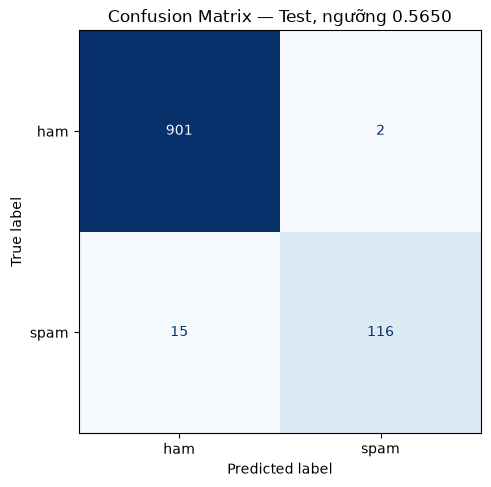

In [11]:
cm = confusion_matrix(y_test, y_pred_final, labels=["ham", "spam"])
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — Test, ngưỡng {chosen_threshold:.4f}")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "confusion_matrix.png", dpi=120)
plt.show()


## 11. In ra 10 tin bị phân loại sai

In [12]:
y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

wrong_mask = y_pred_final != y_test_reset.values
errors_df = pd.DataFrame({
    "text": X_test_reset[wrong_mask],
    "actual": y_test_reset[wrong_mask].values,
    "predicted": y_pred_final[wrong_mask],
    "proba_spam": y_test_proba[wrong_mask],
}).reset_index(drop=True)

print(f"Tổng số ca sai: {len(errors_df)} / {len(y_test)}")
errors_df.head(10)


Tổng số ca sai: 17 / 1034


,text,actual,predicted,proba_spam
0,Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 J...,spam,ham,0.028344
1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT....,spam,ham,0.218669
2,Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 0909972639...,spam,ham,0.013625
3,Missed call alert. These numbers called but left no message. 07008009200,spam,ham,0.039570
4,"FreeMsg Hey U, i just got 1 of these video/pic fones, reply WILD to this txt & ill send U my pics, hurry up Im so bo...",spam,ham,0.344377
5,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about ...,spam,ham,0.002053
6,Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo,spam,ham,0.206400
7,88066 FROM 88066 LOST 3POUND HELP,spam,ham,0.221587
8,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Da...",spam,ham,0.005271
9,"Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & S...",spam,ham,0.136007


## 12. So sánh với Logistic Regression + TF-IDF

In [13]:
logreg_pipe = make_pipeline(
    TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9),
    LogisticRegression(max_iter=1000),
)

t0 = time.perf_counter()
logreg_pipe.fit(X_train, y_train)
logreg_train_time = time.perf_counter() - t0

y_pred_lr = logreg_pipe.predict(X_test)

print(f"Thời gian train Logistic Regression: {logreg_train_time*1000:.1f} ms")
print()
print(classification_report(y_test, y_pred_lr, digits=4))

comparison = pd.DataFrame([
    {
        "model": "Naive Bayes (best, threshold-tuned trên validation)",
        "precision": precision_score(y_test, y_pred_final, pos_label="spam"),
        "recall": recall_score(y_test, y_pred_final, pos_label="spam"),
        "f1": f1_score(y_test, y_pred_final, pos_label="spam"),
    },
    {
        "model": "Naive Bayes (best, default 0.5)",
        "precision": precision_score(y_test, y_pred_default, pos_label="spam"),
        "recall": recall_score(y_test, y_pred_default, pos_label="spam"),
        "f1": f1_score(y_test, y_pred_default, pos_label="spam"),
    },
    {
        "model": "Logistic Regression + TFIDF",
        "precision": precision_score(y_test, y_pred_lr, pos_label="spam"),
        "recall": recall_score(y_test, y_pred_lr, pos_label="spam"),
        "f1": f1_score(y_test, y_pred_lr, pos_label="spam"),
    },
])
comparison


Thời gian train Logistic Regression: 100.0 ms

              precision    recall  f1-score   support

         ham     0.9535    1.0000    0.9762       903
        spam     1.0000    0.6641    0.7982       131

    accuracy                         0.9574      1034
   macro avg     0.9768    0.8321    0.8872      1034
weighted avg     0.9594    0.9574    0.9537      1034



,model,precision,recall,f1
0,"Naive Bayes (best, threshold-tuned trên validation)",0.983051,0.885496,0.931727
1,"Naive Bayes (best, default 0.5)",0.983193,0.893130,0.936000
2,Logistic Regression + TFIDF,1.000000,0.664122,0.798165


## 13. Đo thời gian train , thời gian dự đoán 1 tin

In [14]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

t0 = time.perf_counter()
final_pipe = make_pipeline(
    TfidfVectorizer(**{k.split("__")[1]: v for k, v in grid.best_params_.items() if k.startswith("tfidfvectorizer")},
                     min_df=2, max_df=0.9, sublinear_tf=True),
    MultinomialNB(**{k.split("__")[1]: v for k, v in grid.best_params_.items() if k.startswith("multinomialnb")}),
)
final_pipe.fit(X_train_final, y_train_final)
train_time = time.perf_counter() - t0
print(f"Thời gian train trên {len(X_train_final)} tin (train+validation): {train_time:.3f} giây")

sample = X_test.iloc[[0]]
# warm-up
final_pipe.predict(sample)

n_runs = 100
t0 = time.perf_counter()
for _ in range(n_runs):
    final_pipe.predict(sample)
avg_ms = (time.perf_counter() - t0) / n_runs * 1000
print(f"Thời gian dự đoán trung bình 1 tin (qua {n_runs} lần): {avg_ms:.3f} ms")
print("Đạt yêu cầu < 5ms/tin!" if avg_ms < 5 else "CHƯA đạt yêu cầu < 5ms/tin, cần tối ưu thêm.")


Thời gian train trên 4135 tin (train+validation): 0.108 giây
Thời gian dự đoán trung bình 1 tin (qua 100 lần): 0.646 ms
Đạt yêu cầu < 5ms/tin!


## 14. Lưu model

In [15]:
MODEL_PATH = PROJECT_ROOT / "models" / "nb_pipeline.joblib"
joblib.dump(final_pipe, MODEL_PATH)
print(f"Đã lưu model vào {MODEL_PATH}")

threshold_info = {"threshold": float(chosen_threshold), "positive_class": "spam"}
THRESHOLD_PATH = PROJECT_ROOT / "models" / "threshold.json"
with open(THRESHOLD_PATH, "w", encoding="utf-8") as f:
    json.dump(threshold_info, f, ensure_ascii=False, indent=2)
print(f"Đã lưu ngưỡng: {threshold_info}")
metrics = {
    "best_params": {k: (list(v) if isinstance(v, tuple) else v) for k, v in grid.best_params_.items()},
    "threshold": float(chosen_threshold),
    "test_precision_spam": float(precision_score(y_test, y_pred_final, pos_label="spam")),
    "test_recall_spam": float(recall_score(y_test, y_pred_final, pos_label="spam")),
    "test_f1_spam": float(f1_score(y_test, y_pred_final, pos_label="spam")),
    "train_time_sec": train_time,
    "avg_predict_ms": avg_ms,
}
METRICS_PATH = PROJECT_ROOT / "reports" / "metrics.json"
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print(f"Đã lưu metrics: {METRICS_PATH}")

Đã lưu model vào d:\TT_ML\TT-06-NaiveBayes_Linh\models\nb_pipeline.joblib
Đã lưu ngưỡng: {'threshold': 0.5649556944458224, 'positive_class': 'spam'}
Đã lưu metrics: d:\TT_ML\TT-06-NaiveBayes_Linh\reports\metrics.json
